# Learning Rate Schedules: From Constant to Adaptive

**What we'll learn:**
- Why learning rate schedules improve training
- Step decay, exponential decay, and cosine annealing
- Warmup and why it helps large models
- How to combine schedules for state-of-the-art results

**Core intuition:**
Starting with a large learning rate helps escape bad local minima quickly. Gradually reducing it allows fine-grained optimization near the end. Think of it like finding your house: walk fast on the highway, slow down in your neighborhood, carefully park in your driveway.

## 1. Setup

First, let's import the necessary libraries and set up our environment for reproducibility.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set random seed for reproducibility and configure the device.

In [5]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 2. The Problem: Why Constant Learning Rates Aren't Optimal

Let's create a simple toy problem: fitting a neural network to a noisy sine wave. This will let us visualize how different learning rate schedules affect training.

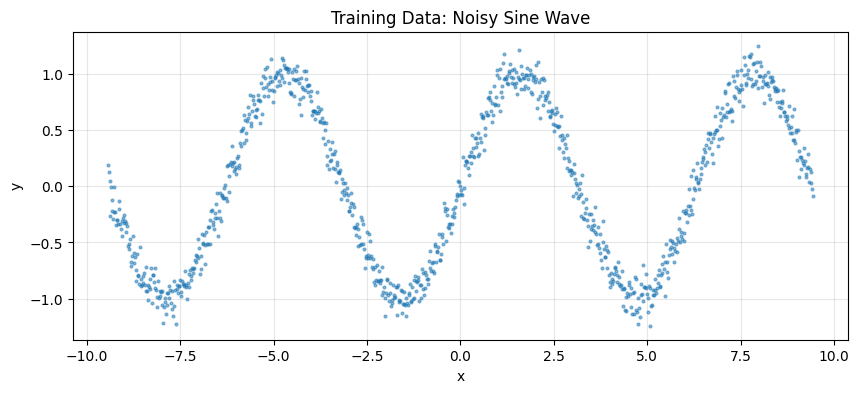

In [6]:
# Generate toy dataset: noisy sine wave
def create_toy_dataset(n_samples=1000):
    X = torch.linspace(-3 * np.pi, 3 * np.pi, n_samples).reshape(-1, 1)
    y = torch.sin(X) + 0.1 * torch.randn_like(X)
    return X.to(device), y.to(device)

X_train, y_train = create_toy_dataset()

# Visualize the data
plt.figure(figsize=(10, 4))
plt.plot(X_train.cpu(), y_train.cpu(), 'o', alpha=0.5, markersize=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data: Noisy Sine Wave')
plt.grid(True, alpha=0.3)
plt.show()

Now let's define a simple neural network to fit this data.

In [7]:
class SimpleNet(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# Test the model
model = SimpleNet().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 4,353


Let's create a training function that records the learning rate and loss at each step.

In [8]:
def train_model(model, optimizer, scheduler, X, y, epochs=200):
    """Train model and track loss and learning rate."""
    model.train()
    criterion = nn.MSELoss()
    
    losses = []
    learning_rates = []
    
    for epoch in range(epochs):
        # Forward pass
        predictions = model(X)
        loss = criterion(predictions, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update learning rate
        if scheduler is not None:
            scheduler.step()
        
        # Record metrics
        losses.append(loss.item())
        learning_rates.append(optimizer.param_groups[0]['lr'])
    
    return losses, learning_rates

Let's train with a **constant learning rate** as our baseline.

In [9]:
# Train with constant learning rate
set_seed(42)
model_constant = SimpleNet().to(device)
optimizer_constant = optim.Adam(model_constant.parameters(), lr=0.01)

losses_constant, lrs_constant = train_model(
    model_constant, optimizer_constant, None, X_train, y_train
)

print(f"Final loss: {losses_constant[-1]:.6f}")

Final loss: 0.102808


Visualize the training dynamics.

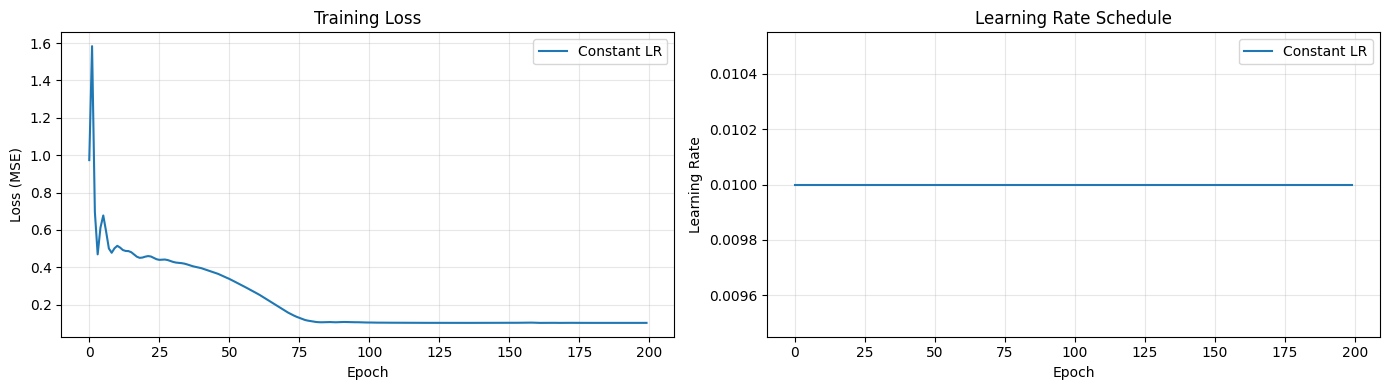

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
ax1.plot(losses_constant, label='Constant LR')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rate
ax2.plot(lrs_constant, label='Constant LR')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** The constant learning rate works, but notice how the loss curve plateaus and oscillates at the end. The learning rate is too large for fine-grained optimization but reducing it from the start would slow down initial progress.

**The key insight:** We want the best of both worlds—fast initial learning and precise final convergence. This is where learning rate schedules come in.

## 3. Step Decay: Discrete Learning Rate Reductions

### 3.1 Intuition

**Step decay** reduces the learning rate by a multiplicative factor every fixed number of epochs.

Formula: $\text{lr} = \text{lr}_0 \times \gamma^{\lfloor \text{epoch} / \text{step\_size} \rfloor}$

Where:
- $\text{lr}_0$ = initial learning rate
- $\gamma$ = decay factor (typically 0.1 or 0.5)
- $\text{step\_size}$ = epochs between reductions

**Analogy:** Like shifting gears in a car—abrupt changes at regular intervals.

### 3.2 Implementation

PyTorch provides `StepLR` scheduler. Let's visualize how it changes the learning rate.

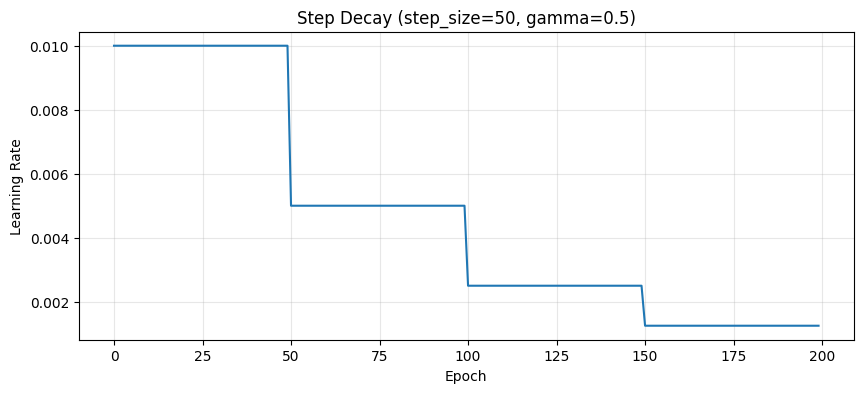

In [11]:
# Visualize step decay schedule
def visualize_schedule(scheduler_fn, epochs=200, title=''):
    """Helper function to visualize a learning rate schedule."""
    dummy_model = SimpleNet().to(device)
    dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=0.01)
    scheduler = scheduler_fn(dummy_optimizer)
    
    lrs = []
    for epoch in range(epochs):
        lrs.append(dummy_optimizer.param_groups[0]['lr'])
        scheduler.step()
    
    plt.figure(figsize=(10, 4))
    plt.plot(lrs)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return lrs

# Step decay: reduce LR by 0.5 every 50 epochs
lrs_step = visualize_schedule(
    lambda opt: optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5),
    title='Step Decay (step_size=50, gamma=0.5)'
)

**Key observation:** The learning rate drops abruptly at epochs 50, 100, 150. This creates "stairs" in the schedule.

### 3.3 Training with Step Decay

Now let's train our model using step decay and compare it to the constant baseline.

In [12]:
# Train with step decay
set_seed(42)
model_step = SimpleNet().to(device)
optimizer_step = optim.Adam(model_step.parameters(), lr=0.01)
scheduler_step = optim.lr_scheduler.StepLR(optimizer_step, step_size=50, gamma=0.5)

losses_step, lrs_step = train_model(
    model_step, optimizer_step, scheduler_step, X_train, y_train
)

print(f"Final loss (constant): {losses_constant[-1]:.6f}")
print(f"Final loss (step decay): {losses_step[-1]:.6f}")
print(f"Improvement: {(1 - losses_step[-1]/losses_constant[-1])*100:.1f}%")

Final loss (constant): 0.102808
Final loss (step decay): 0.103026
Improvement: -0.2%


Compare the training dynamics side by side.

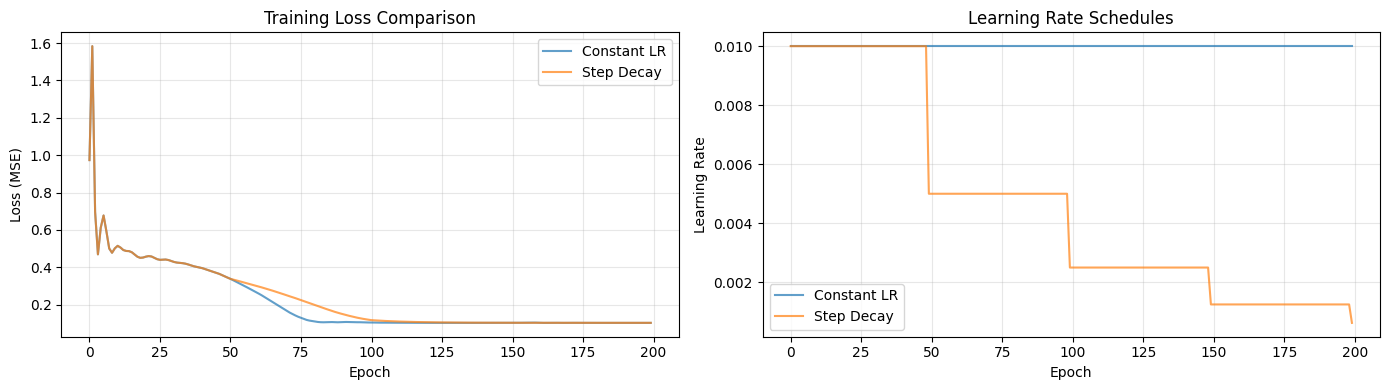

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax1.plot(losses_constant, label='Constant LR', alpha=0.7)
ax1.plot(losses_step, label='Step Decay', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rates
ax2.plot(lrs_constant, label='Constant LR', alpha=0.7)
ax2.plot(lrs_step, label='Step Decay', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedules')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** Notice how the loss drops sharply after each learning rate reduction (epochs 50, 100, 150). The model can make coarse adjustments early, then fine-tune as the learning rate decreases.

**Trade-off:** Step decay is simple but the abrupt changes can cause training instability. The schedule is also rigid—you must choose step size and gamma before training.

## 4. Exponential Decay: Smooth and Continuous

### 4.1 Intuition

**Exponential decay** reduces the learning rate smoothly by a constant factor each epoch.

Formula: $\text{lr} = \text{lr}_0 \times \gamma^{\text{epoch}}$

Where:
- $\text{lr}_0$ = initial learning rate  
- $\gamma$ = decay rate (e.g., 0.95 or 0.99)

**Analogy:** Like a ball rolling down a hill with friction—constantly slowing down.

**Why it works:** Avoids abrupt changes that can destabilize training. The learning rate decreases gradually and continuously.

### 4.2 Visualizing Exponential Decay

Let's see how different gamma values affect the schedule.

<Figure size 1000x400 with 0 Axes>

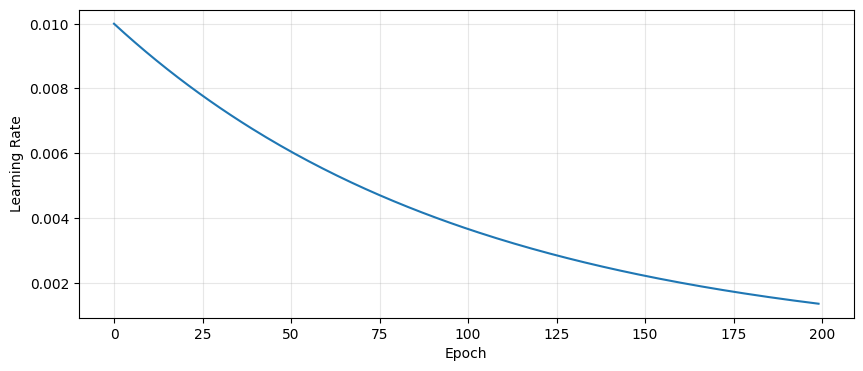

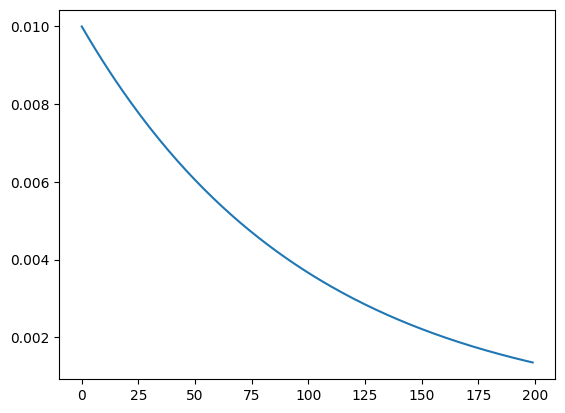

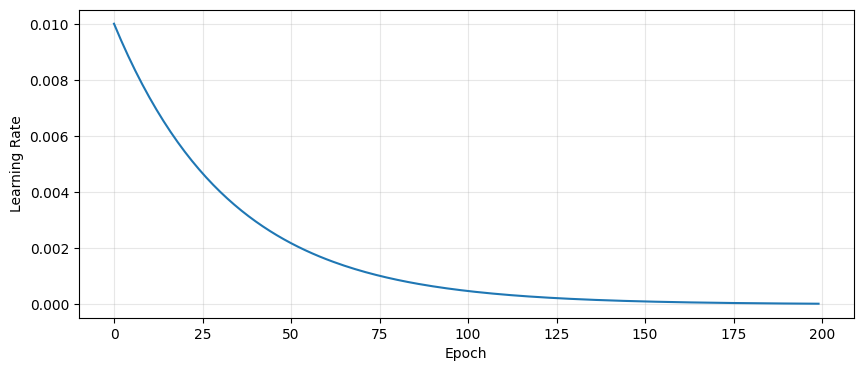

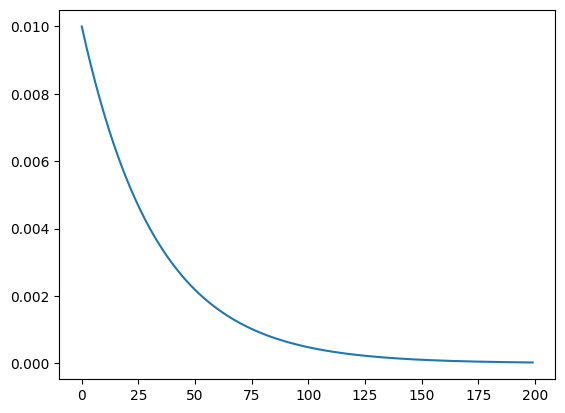

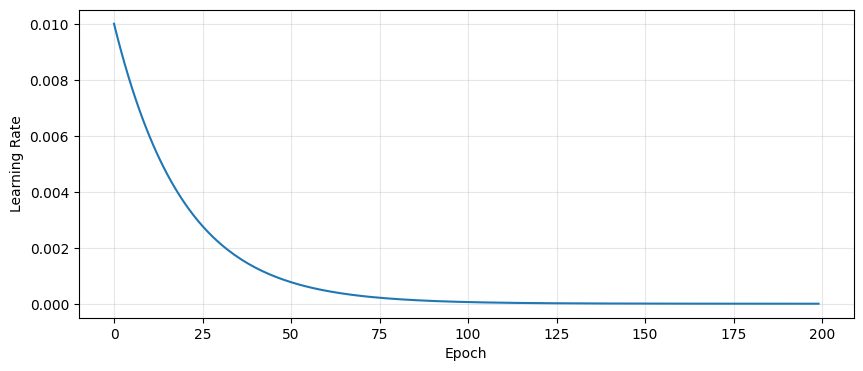

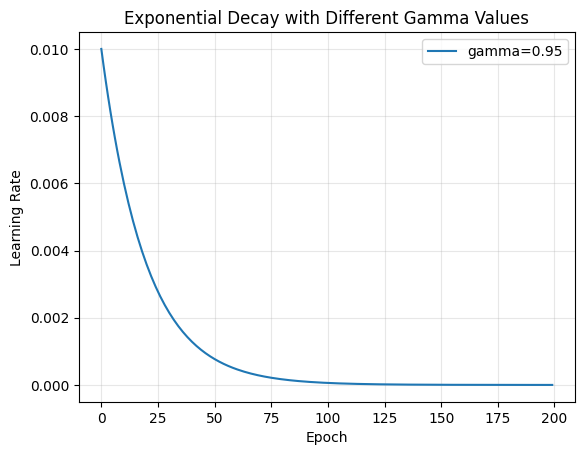

In [14]:
# Compare different gamma values
plt.figure(figsize=(10, 4))

for gamma in [0.99, 0.97, 0.95]:
    lrs = visualize_schedule(
        lambda opt, g=gamma: optim.lr_scheduler.ExponentialLR(opt, gamma=g),
        title=''
    )
    plt.plot(lrs, label=f'gamma={gamma}')

plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Exponential Decay with Different Gamma Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** Smaller gamma (e.g., 0.95) decays faster, while larger gamma (e.g., 0.99) decays more gradually. All curves are smooth, unlike step decay's staircase pattern.

### 4.3 Training with Exponential Decay

In [15]:
# Train with exponential decay
set_seed(42)
model_exp = SimpleNet().to(device)
optimizer_exp = optim.Adam(model_exp.parameters(), lr=0.01)
scheduler_exp = optim.lr_scheduler.ExponentialLR(optimizer_exp, gamma=0.97)

losses_exp, lrs_exp = train_model(
    model_exp, optimizer_exp, scheduler_exp, X_train, y_train
)

print(f"Final loss (constant): {losses_constant[-1]:.6f}")
print(f"Final loss (step decay): {losses_step[-1]:.6f}")
print(f"Final loss (exponential): {losses_exp[-1]:.6f}")

Final loss (constant): 0.102808
Final loss (step decay): 0.103026
Final loss (exponential): 0.350832


Compare all three schedules so far.

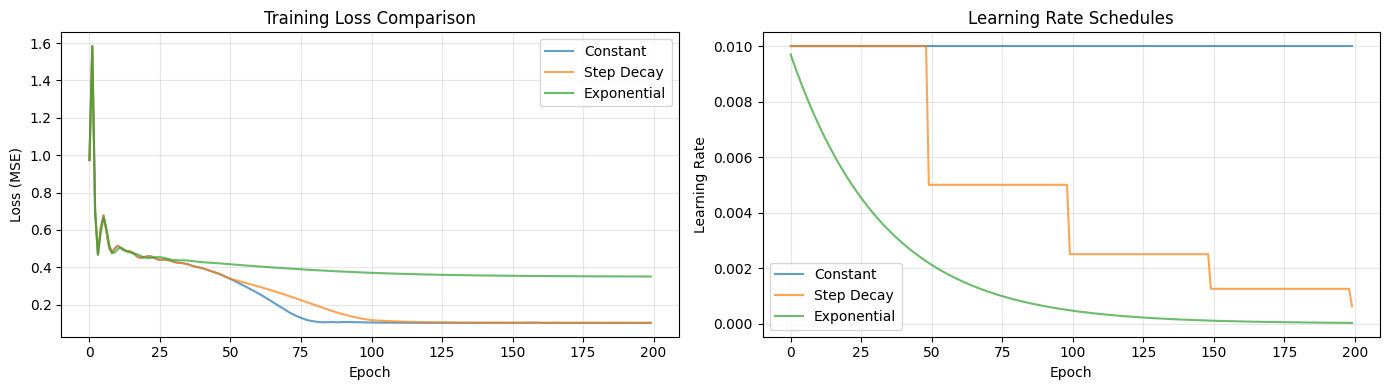

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax1.plot(losses_constant, label='Constant', alpha=0.7)
ax1.plot(losses_step, label='Step Decay', alpha=0.7)
ax1.plot(losses_exp, label='Exponential', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rates
ax2.plot(lrs_constant, label='Constant', alpha=0.7)
ax2.plot(lrs_step, label='Step Decay', alpha=0.7)
ax2.plot(lrs_exp, label='Exponential', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedules')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** Exponential decay provides smoother training than step decay. The loss decreases steadily without the sharp drops. This can lead to more stable training, especially for sensitive models.

## 5. Cosine Annealing: The Modern Standard

### 5.1 Intuition

**Cosine annealing** follows a cosine curve, starting high and smoothly decreasing to a minimum.

Formula: $\text{lr} = \text{lr}_{\text{min}} + \frac{1}{2}(\text{lr}_{\text{max}} - \text{lr}_{\text{min}}) \left(1 + \cos\left(\frac{T_{\text{cur}}}{T_{\text{max}}} \pi\right)\right)$

Where:
- $\text{lr}_{\text{max}}$ = initial learning rate
- $\text{lr}_{\text{min}}$ = minimum learning rate (often 0)
- $T_{\text{cur}}$ = current epoch
- $T_{\text{max}}$ = total epochs

**Why it's popular:**
1. **Smooth decay** with aggressive reduction near the end
2. **Mathematically elegant** and easy to tune
3. **State-of-the-art results** in vision (ResNets) and language models (Transformers)

**Analogy:** Like landing a plane—descend gradually, then aggressively slow down just before touchdown.

### 5.2 Visualizing Cosine Annealing

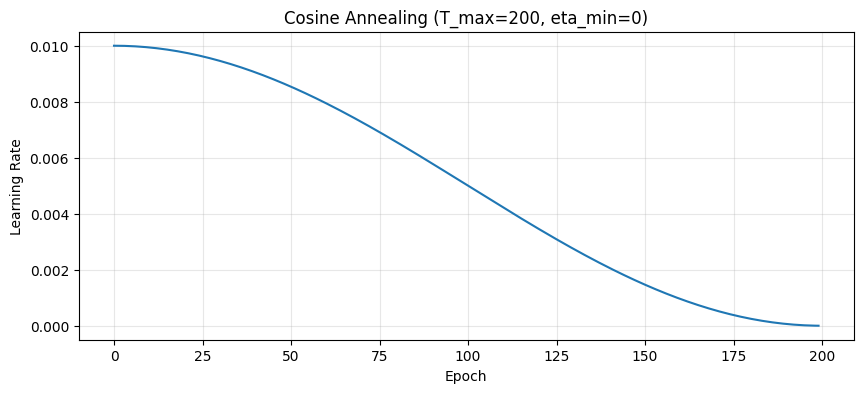

In [17]:
# Visualize cosine annealing
lrs_cosine = visualize_schedule(
    lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200, eta_min=0),
    title='Cosine Annealing (T_max=200, eta_min=0)'
)

Let's compare the shape of cosine annealing to exponential decay.

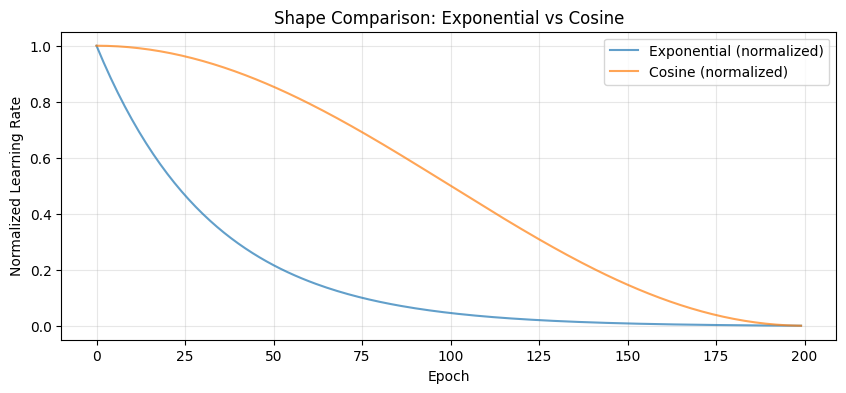

In [18]:
# Compare shapes
plt.figure(figsize=(10, 4))

# Normalize both to [0, 1] for shape comparison
lrs_exp_norm = (np.array(lrs_exp) - min(lrs_exp)) / (max(lrs_exp) - min(lrs_exp))
lrs_cosine_norm = (np.array(lrs_cosine) - min(lrs_cosine)) / (max(lrs_cosine) - min(lrs_cosine))

plt.plot(lrs_exp_norm, label='Exponential (normalized)', alpha=0.7)
plt.plot(lrs_cosine_norm, label='Cosine (normalized)', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Normalized Learning Rate')
plt.title('Shape Comparison: Exponential vs Cosine')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key observation:** Cosine annealing maintains a higher learning rate for longer, then drops more aggressively near the end. Exponential decay is more conservative throughout.

### 5.3 Training with Cosine Annealing

In [19]:
# Train with cosine annealing
set_seed(42)
model_cosine = SimpleNet().to(device)
optimizer_cosine = optim.Adam(model_cosine.parameters(), lr=0.01)
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, T_max=200, eta_min=0)

losses_cosine, lrs_cosine = train_model(
    model_cosine, optimizer_cosine, scheduler_cosine, X_train, y_train
)

print(f"Final loss (constant): {losses_constant[-1]:.6f}")
print(f"Final loss (step decay): {losses_step[-1]:.6f}")
print(f"Final loss (exponential): {losses_exp[-1]:.6f}")
print(f"Final loss (cosine): {losses_cosine[-1]:.6f}")

Final loss (constant): 0.102808
Final loss (step decay): 0.103026
Final loss (exponential): 0.350832
Final loss (cosine): 0.102939


Compare all four schedules.

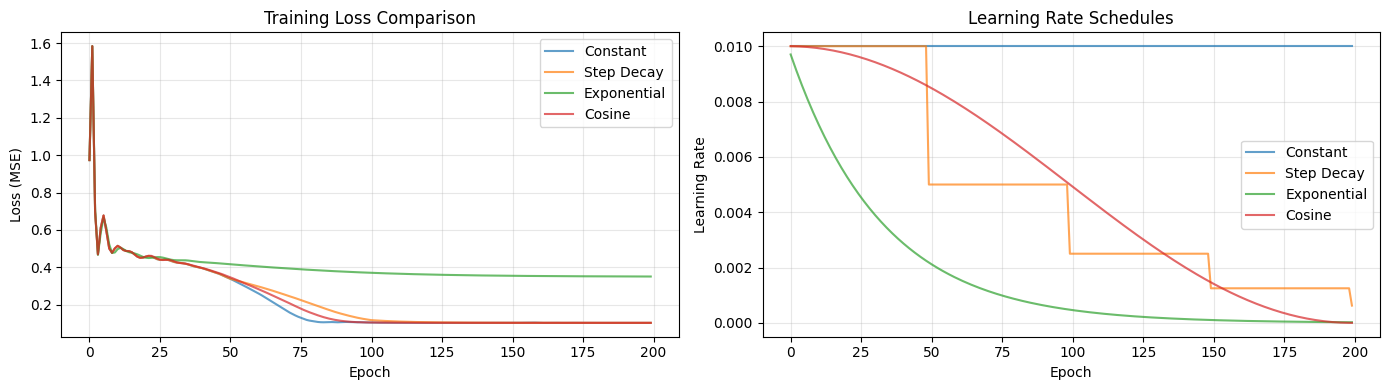

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax1.plot(losses_constant, label='Constant', alpha=0.7)
ax1.plot(losses_step, label='Step Decay', alpha=0.7)
ax1.plot(losses_exp, label='Exponential', alpha=0.7)
ax1.plot(losses_cosine, label='Cosine', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rates
ax2.plot(lrs_constant, label='Constant', alpha=0.7)
ax2.plot(lrs_step, label='Step Decay', alpha=0.7)
ax2.plot(lrs_exp, label='Exponential', alpha=0.7)
ax2.plot(lrs_cosine, label='Cosine', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedules')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** Cosine annealing often achieves the best final loss. It explores aggressively early (high LR) and fine-tunes aggressively late (rapid LR drop), making efficient use of the entire training budget.

## 6. Warmup: Gradual Start for Stability

### 6.1 Intuition

**Warmup** starts with a very small learning rate and gradually increases it to the target value over the first few epochs.

**Why it helps:**
1. **Random initialization** means early gradients can be unstable
2. **Large learning rates** early on can cause the model to diverge
3. **Batch normalization and large models** especially benefit from warmup

**Analogy:** Like warming up a car engine in winter—start gently before going full speed.

**Common in:**
- Transformer models (BERT, GPT)
- Large batch training
- Models with batch normalization

### 6.2 Implementing Linear Warmup

PyTorch doesn't have a built-in warmup scheduler, so let's implement one.

In [21]:
class LinearWarmupScheduler:
    """Linear warmup from 0 to base_lr over warmup_epochs."""
    def __init__(self, optimizer, warmup_epochs, base_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.base_lr = base_lr
        self.current_epoch = 0
    
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (self.current_epoch + 1) / self.warmup_epochs
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        self.current_epoch += 1

Visualize the warmup schedule.

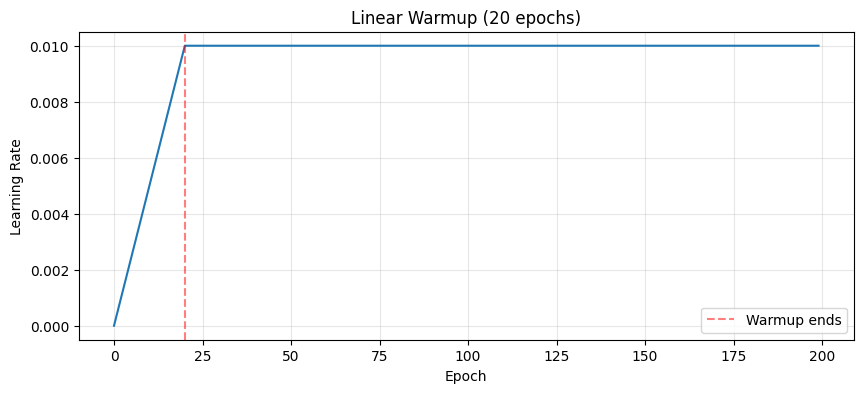

In [22]:
# Visualize warmup
dummy_model = SimpleNet().to(device)
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=0.0)  # Start at 0
warmup_scheduler = LinearWarmupScheduler(dummy_optimizer, warmup_epochs=20, base_lr=0.01)

lrs_warmup = []
for epoch in range(200):
    lrs_warmup.append(dummy_optimizer.param_groups[0]['lr'])
    warmup_scheduler.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs_warmup)
plt.axvline(x=20, color='r', linestyle='--', alpha=0.5, label='Warmup ends')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Linear Warmup (20 epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The learning rate increases linearly from 0 to 0.01 over the first 20 epochs, then stays constant.

### 6.3 Training with Warmup

Let's test warmup alone (without decay afterward).

In [23]:
# Train with warmup only
set_seed(42)
model_warmup = SimpleNet().to(device)
optimizer_warmup = optim.Adam(model_warmup.parameters(), lr=0.0)
scheduler_warmup = LinearWarmupScheduler(optimizer_warmup, warmup_epochs=20, base_lr=0.01)

losses_warmup, lrs_warmup = train_model(
    model_warmup, optimizer_warmup, scheduler_warmup, X_train, y_train
)

print(f"Final loss (constant): {losses_constant[-1]:.6f}")
print(f"Final loss (warmup): {losses_warmup[-1]:.6f}")

Final loss (constant): 0.102808
Final loss (warmup): 0.078262


Compare warmup to constant learning rate.

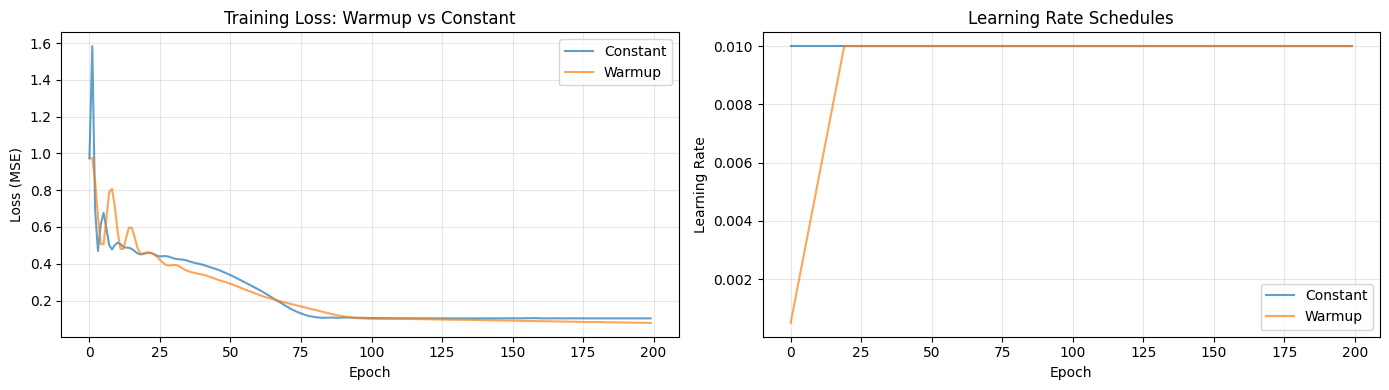

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax1.plot(losses_constant, label='Constant', alpha=0.7)
ax1.plot(losses_warmup, label='Warmup', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss: Warmup vs Constant')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rates
ax2.plot(lrs_constant, label='Constant', alpha=0.7)
ax2.plot(lrs_warmup, label='Warmup', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedules')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** Warmup by itself doesn't help much for this simple problem. But it becomes critical for:
1. **Large models** with unstable early gradients
2. **Large batch sizes** where gradient estimates are noisier initially
3. **Transformer architectures** which are particularly sensitive to initialization

Warmup's true power comes when **combined with decay schedules**.

## 7. Combining Schedules: Warmup + Cosine Annealing

### 7.1 The State-of-the-Art Recipe

Modern deep learning typically combines **warmup** and **cosine annealing**:
1. **Warmup phase**: Increase LR from 0 to max over first N epochs
2. **Cosine decay phase**: Decrease LR following cosine curve

This is the default in many Transformer implementations (BERT, GPT, Vision Transformers).

### 7.2 Implementation

Let's create a combined warmup + cosine scheduler.

In [25]:
class WarmupCosineScheduler:
    """Warmup followed by cosine annealing."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr, min_lr=0):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.current_epoch = 0
    
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Warmup: linear increase
            lr = self.base_lr * (self.current_epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        self.current_epoch += 1

Visualize the combined schedule.

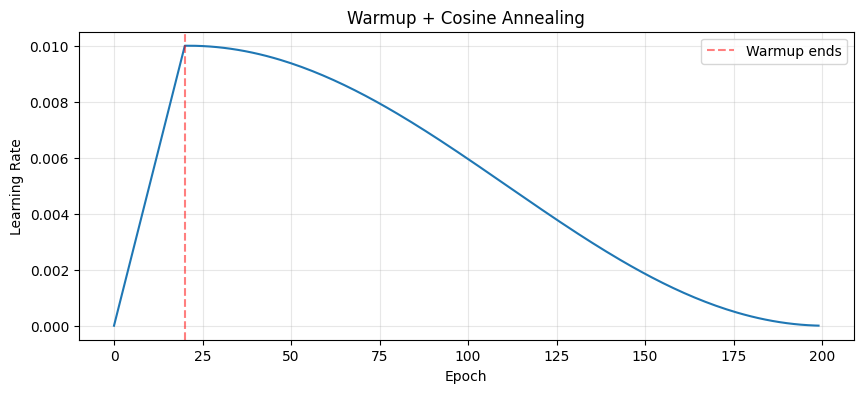

In [26]:
# Visualize warmup + cosine
dummy_model = SimpleNet().to(device)
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=0.0)
combined_scheduler = WarmupCosineScheduler(
    dummy_optimizer, warmup_epochs=20, total_epochs=200, base_lr=0.01, min_lr=0
)

lrs_combined = []
for epoch in range(200):
    lrs_combined.append(dummy_optimizer.param_groups[0]['lr'])
    combined_scheduler.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs_combined)
plt.axvline(x=20, color='r', linestyle='--', alpha=0.5, label='Warmup ends')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Warmup + Cosine Annealing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Perfect!** The learning rate increases linearly during warmup (epochs 0-20), then follows a smooth cosine decay.

### 7.3 Training with Warmup + Cosine

In [27]:
# Train with warmup + cosine
set_seed(42)
model_combined = SimpleNet().to(device)
optimizer_combined = optim.Adam(model_combined.parameters(), lr=0.0)
scheduler_combined = WarmupCosineScheduler(
    optimizer_combined, warmup_epochs=20, total_epochs=200, base_lr=0.01, min_lr=0
)

losses_combined, lrs_combined = train_model(
    model_combined, optimizer_combined, scheduler_combined, X_train, y_train
)

print("Final losses:")
print(f"  Constant: {losses_constant[-1]:.6f}")
print(f"  Step decay: {losses_step[-1]:.6f}")
print(f"  Exponential: {losses_exp[-1]:.6f}")
print(f"  Cosine: {losses_cosine[-1]:.6f}")
print(f"  Warmup + Cosine: {losses_combined[-1]:.6f}")

Final losses:
  Constant: 0.102808
  Step decay: 0.103026
  Exponential: 0.350832
  Cosine: 0.102939
  Warmup + Cosine: 0.087983


## 8. Final Comparison: All Schedules

Let's create a comprehensive comparison of all schedules we've studied.

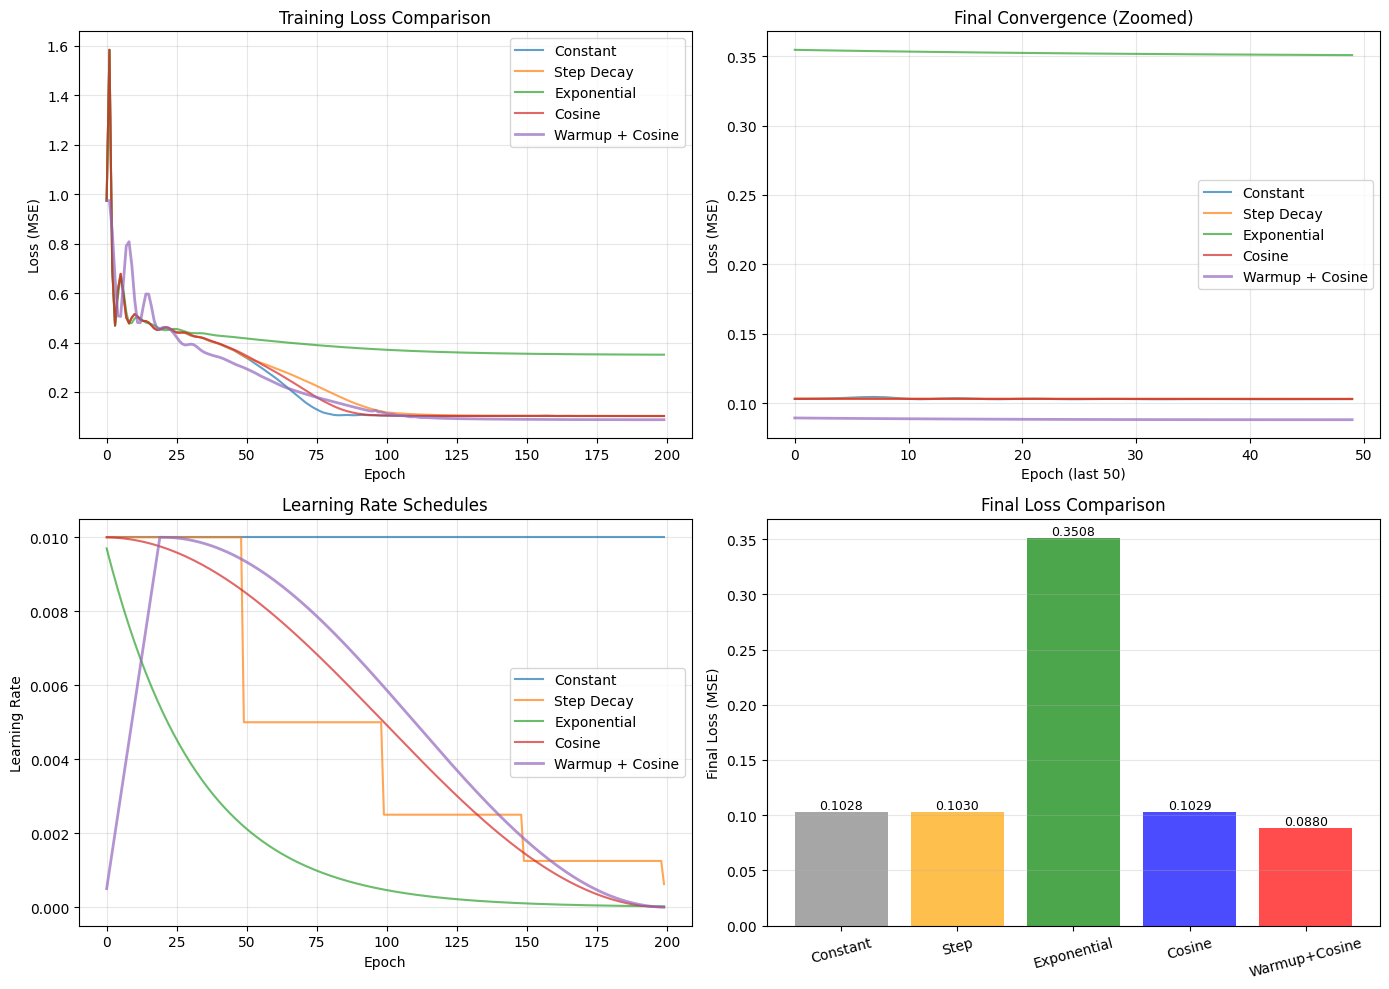

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
ax1 = axes[0, 0]
ax1.plot(losses_constant, label='Constant', alpha=0.7)
ax1.plot(losses_step, label='Step Decay', alpha=0.7)
ax1.plot(losses_exp, label='Exponential', alpha=0.7)
ax1.plot(losses_cosine, label='Cosine', alpha=0.7)
ax1.plot(losses_combined, label='Warmup + Cosine', alpha=0.7, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss curves (zoomed to final 50 epochs)
ax2 = axes[0, 1]
ax2.plot(losses_constant[150:], label='Constant', alpha=0.7)
ax2.plot(losses_step[150:], label='Step Decay', alpha=0.7)
ax2.plot(losses_exp[150:], label='Exponential', alpha=0.7)
ax2.plot(losses_cosine[150:], label='Cosine', alpha=0.7)
ax2.plot(losses_combined[150:], label='Warmup + Cosine', alpha=0.7, linewidth=2)
ax2.set_xlabel('Epoch (last 50)')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Final Convergence (Zoomed)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning rate schedules
ax3 = axes[1, 0]
ax3.plot(lrs_constant, label='Constant', alpha=0.7)
ax3.plot(lrs_step, label='Step Decay', alpha=0.7)
ax3.plot(lrs_exp, label='Exponential', alpha=0.7)
ax3.plot(lrs_cosine, label='Cosine', alpha=0.7)
ax3.plot(lrs_combined, label='Warmup + Cosine', alpha=0.7, linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_title('Learning Rate Schedules')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Final loss comparison (bar chart)
ax4 = axes[1, 1]
schedules = ['Constant', 'Step', 'Exponential', 'Cosine', 'Warmup+Cosine']
final_losses = [
    losses_constant[-1],
    losses_step[-1],
    losses_exp[-1],
    losses_cosine[-1],
    losses_combined[-1]
]
colors = ['gray', 'orange', 'green', 'blue', 'red']
bars = ax4.bar(schedules, final_losses, color=colors, alpha=0.7)
ax4.set_ylabel('Final Loss (MSE)')
ax4.set_title('Final Loss Comparison')
ax4.grid(True, alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=15)

# Add value labels on bars
for bar, loss in zip(bars, final_losses):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{loss:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Summary Statistics

In [29]:
print("="*60)
print("FINAL RESULTS")
print("="*60)

baseline_loss = losses_constant[-1]

results = [
    ("Constant LR", losses_constant[-1]),
    ("Step Decay", losses_step[-1]),
    ("Exponential Decay", losses_exp[-1]),
    ("Cosine Annealing", losses_cosine[-1]),
    ("Warmup + Cosine", losses_combined[-1]),
]

for name, loss in results:
    improvement = (1 - loss/baseline_loss) * 100
    print(f"{name:20s}: {loss:.6f}  (improvement: {improvement:+.1f}%)")

print("="*60)

FINAL RESULTS
Constant LR         : 0.102808  (improvement: +0.0%)
Step Decay          : 0.103026  (improvement: -0.2%)
Exponential Decay   : 0.350832  (improvement: -241.2%)
Cosine Annealing    : 0.102939  (improvement: -0.1%)
Warmup + Cosine     : 0.087983  (improvement: +14.4%)


## 9. When to Use Each Schedule

### Practical Guidelines

| Schedule | Best For | Pros | Cons |
|----------|----------|------|------|
| **Constant** | Quick experiments, baseline | Simple, one hyperparameter | Suboptimal convergence |
| **Step Decay** | CNNs, classic vision models | Easy to implement, interpretable | Requires tuning step size, abrupt changes |
| **Exponential** | RNNs, general-purpose | Smooth, predictable | One more hyperparameter (gamma) |
| **Cosine** | Modern CNNs, ResNets | State-of-the-art, no tuning | Requires knowing total epochs |
| **Warmup + Cosine** | Transformers, large models | Best for large-scale training | More complex |

### Quick Decision Tree

1. **Training a Transformer?** → Use **Warmup + Cosine**
2. **Large batch size (>256)?** → Add **Warmup** (5-10% of total epochs)
3. **Vision model (CNN)?** → **Cosine** or **Step Decay**
4. **Quick experiment?** → **Constant** or **Exponential**
5. **Following a paper?** → Use their schedule!

### Hyperparameter Tips

**Step Decay:**
- `step_size`: 30-50 epochs for medium networks
- `gamma`: 0.1 (aggressive) or 0.5 (conservative)

**Exponential:**
- `gamma`: 0.95-0.99 (higher = slower decay)
- Rule of thumb: 0.97 for 200 epochs, 0.99 for 1000 epochs

**Cosine:**
- `T_max`: Total training epochs
- `eta_min`: Usually 0, or 10% of initial LR

**Warmup:**
- Duration: 5-10% of total epochs (e.g., 5-10 epochs for 100 total)
- More critical for: Transformers, large batches, layer normalization

## 10. Advanced: Cosine Annealing with Restarts

An advanced variant called **Cosine Annealing with Warm Restarts (SGDR)** periodically "restarts" the learning rate back to a high value. This can help escape local minima.

Let's visualize what this looks like.

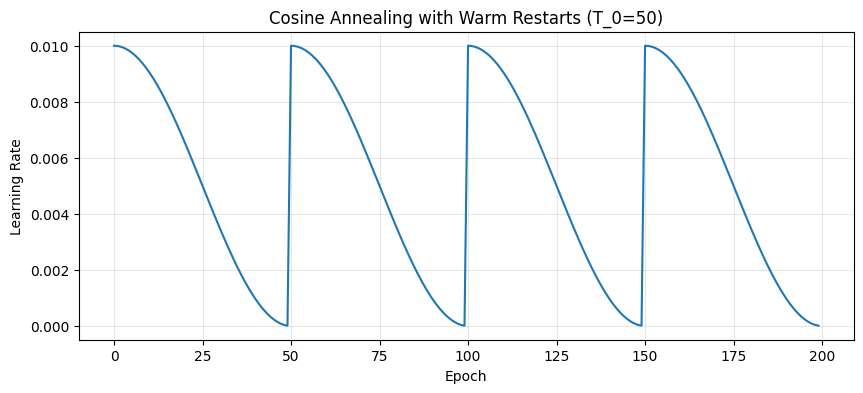

In [30]:
# Visualize cosine annealing with restarts
dummy_model = SimpleNet().to(device)
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=0.01)
scheduler_restart = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    dummy_optimizer, T_0=50, T_mult=1, eta_min=0
)

lrs_restart = []
for epoch in range(200):
    lrs_restart.append(dummy_optimizer.param_groups[0]['lr'])
    scheduler_restart.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs_restart)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine Annealing with Warm Restarts (T_0=50)')
plt.grid(True, alpha=0.3)
plt.show()

**How it works:** Every `T_0` epochs (here 50), the learning rate "restarts" to the initial value and decays again. This gives the model multiple chances to escape poor local minima.

**When to use:** Experimental research, ensemble methods (snapshot ensembles), or when training seems stuck. Not as common as standard cosine annealing.

## 11. Key Takeaways

### Core Intuitions

1. **Constant learning rates are suboptimal** — they either converge slowly (too small) or oscillate (too large)

2. **Learning rate schedules solve the tradeoff** — start high for fast progress, decay for fine-tuning

3. **Step decay** is simple but creates abrupt changes that can destabilize training

4. **Exponential decay** is smooth and predictable, good for general use

5. **Cosine annealing** is the modern standard — maintains high LR longer, then aggressive final decay

6. **Warmup prevents early instability** — critical for Transformers and large models

7. **Warmup + Cosine is state-of-the-art** — used in BERT, GPT, Vision Transformers

### Practical Rules

- **Default choice:** Cosine annealing (no warmup needed for small models)
- **Large models/batches:** Add 5-10% warmup
- **Following a paper:** Use their schedule
- **Debugging/prototyping:** Constant LR is fine

### Mathematical Essence

All schedules answer the same question: **"How should the learning rate change over time?"**

- **Step:** $\text{lr} = \text{lr}_0 \times \gamma^{\lfloor \text{epoch} / \text{step\_size} \rfloor}$
- **Exponential:** $\text{lr} = \text{lr}_0 \times \gamma^{\text{epoch}}$
- **Cosine:** $\text{lr} = \text{lr}_{\text{min}} + \frac{1}{2}(\text{lr}_{\text{max}} - \text{lr}_{\text{min}}) (1 + \cos(\pi t))$
- **Warmup:** $\text{lr} = \text{lr}_{\text{max}} \times \frac{\text{epoch}}{\text{warmup\_epochs}}$

## 12. Experimentation Playground

Now it's your turn! Modify the code below to experiment with different schedules.

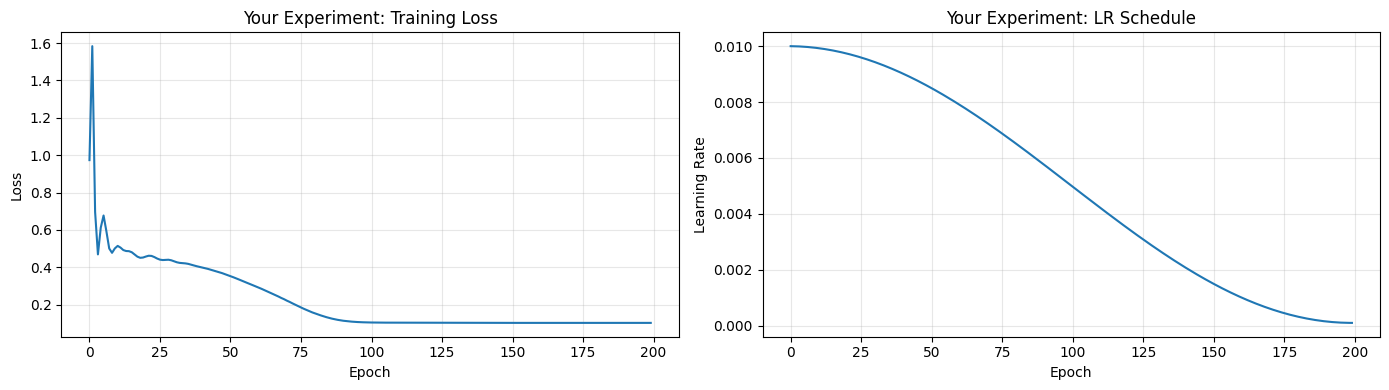

Final loss: 0.102944


In [31]:
# Experiment: Try your own schedule!
set_seed(42)
model_experiment = SimpleNet().to(device)
optimizer_experiment = optim.Adam(model_experiment.parameters(), lr=0.01)

# TODO: Try different schedulers:
# - StepLR with different step_size and gamma
# - ExponentialLR with different gamma
# - CosineAnnealingLR with different T_max
# - Your own custom scheduler!

scheduler_experiment = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_experiment, T_max=200, eta_min=0.0001  # Try eta_min > 0
)

losses_experiment, lrs_experiment = train_model(
    model_experiment, optimizer_experiment, scheduler_experiment, X_train, y_train
)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses_experiment)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Your Experiment: Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(lrs_experiment)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Your Experiment: LR Schedule')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss: {losses_experiment[-1]:.6f}")

### Questions to Explore

1. What happens if you use a very long warmup (e.g., 50% of total epochs)?
2. How does `eta_min` in cosine annealing affect final performance?
3. Can you design a custom schedule that outperforms warmup + cosine?
4. What if you combine step decay with warmup?
5. How do these schedules perform on a harder dataset or deeper model?

**Tip:** The best schedule is often task-dependent. Always validate on your specific problem!